# Predicción del Nivel de Desempeño en las Pruebas Saber 11
## Proyecto Final — Aprendizaje de Máquina (202610)
### Maestría en Inteligencia Artificial — Pontificia Universidad Javeriana

---
| Campo | Detalle |
|-------|---------|
| **Autores** | Carlos Manuel Carvajales Castrillo · Mateo Ruiz Mendoza |
| **Dataset** | Resultados Únicos Saber 11 — datos.gov.co |
| **Períodos** | 20221 y 20224 |
| **Lenguaje** | Python 3.10 |
| **Fecha** | Mayo 2026 |


## 1. Introducción

### 1.1 Contexto del Problema

Las pruebas **Saber 11**, administradas por el Instituto Colombiano para la Evaluación de la
Educación (ICFES), son el examen de Estado más importante para los estudiantes de educación
media en Colombia. Cada semestre más de 500 000 estudiantes presentan esta prueba, generando
uno de los datasets educativos más ricos del país.

El desempeño en el Saber 11 no depende únicamente de factores intrínsecos al estudiante:
variables socioeconómicas del entorno familiar, características del establecimiento educativo y
el acceso a recursos tecnológicos también inciden de manera significativa. Comprender y modelar
estas relaciones tiene valor directo para la formulación de políticas públicas educativas.

---

### 1.2 Motivación

El presente proyecto parte de la siguiente pregunta de investigación:

> **¿Es posible predecir el nivel de desempeño global de un estudiante en el Saber 11
> a partir exclusivamente de variables socioeconómicas y contextuales,
> sin utilizar sus puntajes individuales por prueba?**

Esta pregunta es relevante porque:
- Permite identificar **factores de riesgo antes** de la presentación de la prueba.
- Evita el *data leakage* que surgiría de usar los puntajes por componente como predictores del puntaje global.
- Tiene valor práctico real para instituciones que deseen identificar y apoyar estudiantes en riesgo.

---

### 1.3 Objetivos

**Objetivo General:**
Construir un modelo de clasificación multiclase que prediga el nivel de desempeño global de
estudiantes en el Saber 11 usando exclusivamente variables socioeconómicas y contextuales.

**Objetivos Específicos:**
1. Adquirir y explorar el dataset de resultados Saber 11 para los períodos **20221 y 20224** vía API.
2. Implementar y comparar cuatro modelos de ML: **Regresión Logística, Random Forest, XGBoost y Red Neuronal** (TF/Keras).
3. Evaluar el impacto de dos estrategias de manejo de nulos: **eliminación** e **imputación**.
4. Identificar las variables socioeconómicas más influyentes en la predicción del desempeño.
5. Analizar el rendimiento de los modelos mediante métricas estándar de clasificación multiclase.

---

### 1.4 Descripción del Dataset

El dataset proviene del portal de **Datos Abiertos del Gobierno de Colombia** ([datos.gov.co](https://www.datos.gov.co)).
Cada registro corresponde a un estudiante e incluye:

| Grupo | Variables representativas |
|-------|--------------------------|
| Demográficas | `estu_genero`, `estu_edad`, municipio |
| Establecimiento | `cole_naturaleza`, `cole_calendario`, `cole_bilingue`, `cole_area_ubicacion` |
| Socioeconómicas | `fami_estratovivienda`, `fami_educacionpadre`, `fami_educacionmadre` |
| Tecnología/Bienes | `fami_tieneinternet`, `fami_tienecomputador`, `fami_tieneautomovil`, etc. |
| Puntajes (excluidos) | `punt_lectura_critica`, `punt_matematicas`, `punt_global`, etc. |

> ⚠️ **Importante:** Los puntajes individuales (`punt_*`) y el puntaje global (`punt_global`)
> se excluyen como predictores para evitar fuga de información.
> El `punt_global` se usa **solo** para construir la variable objetivo.

---

### 1.5 Relevancia del Estudio

Este proyecto contribuye al campo del *Educational Data Mining* (EDM). La capacidad de predecir
el desempeño a partir de factores socioeconómicos tiene implicaciones en:

- Diseño de programas de apoyo focalizado para estudiantes vulnerables.
- Evaluación del impacto de políticas de reducción de brechas educativas.
- Análisis de equidad educativa en el sistema colombiano.


## 2. Configuración del Entorno

Cargamos todas las dependencias necesarias para el proyecto.

In [ ]:
# ── Instalación (ejecutar solo si las dependencias no están disponibles) ─────
# !pip install sodapy xgboost tensorflow scikit-learn pandas matplotlib seaborn pyarrow

In [27]:
# ── Librerías estándar ────────────────────────────────────────────────────────
import os
import time
import warnings
import json
from collections import Counter

# ── Datos ────────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd

# ── Visualización ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

# ── Scikit-learn ──────────────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import (
    OrdinalEncoder, StandardScaler, LabelEncoder, OneHotEncoder
)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.base import clone
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, f1_score, precision_score, recall_score
)
from sklearn.utils.class_weight import compute_class_weight

# ── XGBoost ───────────────────────────────────────────────────────────────────
from xgboost import XGBClassifier
import xgboost as xgb

# ── TensorFlow / Keras ────────────────────────────────────────────────────────
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks

# ── API Socrata ───────────────────────────────────────────────────────────────
from sodapy import Socrata

# ── Configuraciones globales ──────────────────────────────────────────────────
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 60)
pd.set_option('display.float_format', '{:.4f}'.format)
np.random.seed(42)
tf.random.set_seed(42)

sns.set_theme(style='whitegrid', palette='Set2', font_scale=1.1)
plt.rcParams.update({'figure.dpi': 110, 'figure.figsize': (10, 5)})

print('✅ Entorno configurado.')
print(f'   NumPy:       {np.__version__}')
print(f'   Pandas:      {pd.__version__}')
print(f'   XGBoost:     {xgb.__version__}')
print(f'   TensorFlow:  {tf.__version__}')


✅ Entorno configurado.
   NumPy:       2.3.2
   Pandas:      2.3.2
   XGBoost:     3.1.0
   TensorFlow:  2.21.0


## 3. Adquisición de Datos

### 3.1 Fuente y Dataset

| Parámetro | Valor |
|-----------|-------|
| Portal | [datos.gov.co](https://www.datos.gov.co) |
| Dataset ID | `kgxf-xxbe` |
| API | Socrata Open Data API (SODA) |

### 3.2 Justificación de los Períodos 20221 y 20224

Se seleccionan **exclusivamente** los períodos **20221** (primer semestre de 2022) y
**20224** (segundo semestre de 2022) por las siguientes razones:

| Criterio | Justificación |
|----------|--------------|
| **Recencia** | Son los períodos más recientes con datos completos y auditados por el ICFES |
| **Volumen** | Juntos superan el millón de registros, garantizando robustez estadística |
| **Homogeneidad** | Pertenecer al mismo año evita sesgos por cambios curriculares o coyunturales |
| **Representatividad** | Usar ambos semestres del mismo año captura variaciones estacionales de la prueba |

> ⚠️ No se utilizan otros períodos para mantener la coherencia metodológica del estudio.

### 3.3 Estrategia de Descarga: Paginación

La API de Socrata limita los registros por solicitud. Por tanto se implementa **paginación**:

- `PAGE_SIZE = 10 000`: Balance entre rendimiento y estabilidad de red.
- **Reintento automático**: Si una solicitud falla, se espera 5 s y se reintenta.
- **Pausa entre bloques** (0.5 s): Para respetar los rate limits de la API.
- **Condición de parada**: Cuando un bloque devuelve menos registros de los solicitados.

### 3.4 Almacenamiento en Parquet

Los datos se guardan en **Apache Parquet** por:
- Compresión eficiente (5–10× menor que CSV).
- Preservación exacta de tipos de datos entre sesiones.
- Lectura columnar y rápida en ejecuciones posteriores (caché local).


In [28]:
# ── Parámetros de descarga ────────────────────────────────────────────────────
DATASET_ID = 'kgxf-xxbe'
PAGE_SIZE  = 10_000
RAW_PATH   = 'saber11_20221_20224.parquet'
PERIODOS   = ['20221', '20224']   # ÚNICAMENTE estos dos períodos

print(f'Dataset ID : {DATASET_ID}')
print(f'Page size  : {PAGE_SIZE:,} registros/bloque')
print(f'Caché path : {RAW_PATH}')
print(f'Períodos   : {PERIODOS}')


Dataset ID : kgxf-xxbe
Page size  : 10,000 registros/bloque
Caché path : saber11_20221_20224.parquet
Períodos   : ['20221', '20224']


In [29]:
# ── Descarga paginada por período ────────────────────────────────────────────
if os.path.exists(RAW_PATH):
    print(f'📂 Cargando desde caché: {RAW_PATH}')
    df_raw = pd.read_parquet(RAW_PATH)
else:
    print('🌐 Conectando a la API de datos.gov.co...')
    client = Socrata(
        'www.datos.gov.co',
        None,          # acceso anónimo (lectura pública)
        timeout=300
    )
    all_records = []

    for periodo in PERIODOS:
        print(f'\n📥 Descargando período {periodo}...')
        offset, total_periodo = 0, 0

        while True:
            try:
                batch = client.get(
                    DATASET_ID,
                    where=f"periodo = '{periodo}'",
                    limit=PAGE_SIZE,
                    offset=offset
                )
            except Exception as e:
                print(f'⚠️  Error en offset {offset}: {e} — reintentando en 5 s...')
                time.sleep(5)
                batch = client.get(
                    DATASET_ID,
                    where=f"periodo = '{periodo}'",
                    limit=PAGE_SIZE,
                    offset=offset
                )

            if not batch:
                print(f'✅ Fin de descarga para {periodo}')
                break

            all_records.extend(batch)
            batch_size     = len(batch)
            total_periodo += batch_size
            offset        += PAGE_SIZE

            print(f'   ✔ {periodo} | batch={batch_size:,} | acum={total_periodo:,}')

            if batch_size < PAGE_SIZE:
                print(f'✅ Último bloque para {periodo}')
                break
            time.sleep(0.5)

    df_raw = pd.DataFrame.from_records(all_records)
    df_raw.to_parquet(RAW_PATH, index=False)
    print(f'\n✅ {len(df_raw):,} registros guardados en "{RAW_PATH}"')

# ── Resumen ───────────────────────────────────────────────────────────────────
print(f'\n📊 Dimensiones: {df_raw.shape[0]:,} filas × {df_raw.shape[1]} columnas')
print('\n📌 Registros por período:')
display(
    df_raw['periodo']
    .value_counts()
    .sort_index(ascending=False)
    .rename('Registros')
    .to_frame()
    .assign(Porcentaje_pct=lambda x: (x['Registros'] / x['Registros'].sum() * 100).round(2))
)


📂 Cargando desde caché: saber11_20221_20224.parquet



📊 Dimensiones: 1,085,937 filas × 51 columnas

📌 Registros por período:


,Registros,Porcentaje_pct
periodo,,
20224,1065888,98.1500
20221,20049,1.8500


### 3.5 Validación de la Descarga

Verificamos que la descarga fue completa y correcta antes de continuar.

In [30]:
# ── Validación ────────────────────────────────────────────────────────────────
print('=' * 60)
print('  VALIDACIÓN DE LA DESCARGA')
print('=' * 60)

periodos_presentes = df_raw['periodo'].unique().tolist()
assert '20221' in periodos_presentes, '❌ Período 20221 no encontrado'
assert '20224' in periodos_presentes, '❌ Período 20224 no encontrado'
print(f'\n✅ Total registros  : {df_raw.shape[0]:,}')
print(f'✅ Total columnas    : {df_raw.shape[1]}')
print(f'✅ Períodos presentes: {sorted(periodos_presentes)}')
print('\n📋 Lista de columnas:')
print(df_raw.columns.tolist())


  VALIDACIÓN DE LA DESCARGA

✅ Total registros  : 1,085,937
✅ Total columnas    : 51
✅ Períodos presentes: ['20221', '20224']

📋 Lista de columnas:
['periodo', 'estu_tipodocumento', 'estu_consecutivo', 'cole_area_ubicacion', 'cole_calendario', 'cole_caracter', 'cole_cod_dane_establecimiento', 'cole_cod_dane_sede', 'cole_cod_depto_ubicacion', 'cole_cod_mcpio_ubicacion', 'cole_codigo_icfes', 'cole_depto_ubicacion', 'cole_genero', 'cole_jornada', 'cole_mcpio_ubicacion', 'cole_naturaleza', 'cole_nombre_establecimiento', 'cole_nombre_sede', 'cole_sede_principal', 'estu_cod_depto_presentacion', 'estu_cod_mcpio_presentacion', 'estu_cod_reside_depto', 'estu_cod_reside_mcpio', 'estu_depto_presentacion', 'estu_depto_reside', 'estu_estadoinvestigacion', 'estu_estudiante', 'estu_fechanacimiento', 'estu_genero', 'estu_mcpio_presentacion', 'estu_mcpio_reside', 'estu_nacionalidad', 'estu_pais_reside', 'estu_privado_libertad', 'fami_cuartoshogar', 'fami_educacionmadre', 'fami_educacionpadre', 'fami_es

## 4. Exploración y Análisis de Datos (EDA)

El EDA tiene por objetivo comprender la estructura del dataset, identificar problemas de calidad
y generar hipótesis que guíen el preprocesamiento y modelado.

### 4.1 Vista General y Tipos de Variables


In [31]:
# ── Primeras filas ────────────────────────────────────────────────────────────
print('📋 Primeras 3 filas:')
display(df_raw.head(3))


📋 Primeras 3 filas:


,periodo,estu_tipodocumento,estu_consecutivo,cole_area_ubicacion,cole_calendario,cole_caracter,cole_cod_dane_establecimiento,cole_cod_dane_sede,cole_cod_depto_ubicacion,cole_cod_mcpio_ubicacion,cole_codigo_icfes,cole_depto_ubicacion,cole_genero,cole_jornada,cole_mcpio_ubicacion,cole_naturaleza,cole_nombre_establecimiento,cole_nombre_sede,cole_sede_principal,estu_cod_depto_presentacion,estu_cod_mcpio_presentacion,estu_cod_reside_depto,estu_cod_reside_mcpio,estu_depto_presentacion,estu_depto_reside,estu_estadoinvestigacion,estu_estudiante,estu_fechanacimiento,estu_genero,estu_mcpio_presentacion,estu_mcpio_reside,estu_nacionalidad,estu_pais_reside,estu_privado_libertad,fami_cuartoshogar,fami_educacionmadre,fami_educacionpadre,fami_estratovivienda,fami_personashogar,fami_tieneautomovil,fami_tienecomputador,fami_tieneinternet,fami_tienelavadora,desemp_ingles,punt_ingles,punt_matematicas,punt_sociales_ciudadanas,punt_c_naturales,punt_lectura_critica,punt_global,cole_bilingue
0,20221,TI,AC202210004339,URBANO,B,ACADÉMICO,376520005862,376520005862,76,76520,129601,VALLE,MIXTO,COMPLETA,PALMIRA,NO OFICIAL,LIC CAMPESTRE CRECER,LIC CAMPESTRE CRECER,S,76,76520,76,76520,VALLE,VALLE,PUBLICAR,ESTUDIANTE,27/06/2005,M,PALMIRA,PALMIRA,COLOMBIA,COLOMBIA,N,Tres,Educación profesional completa,Postgrado,Estrato 3,3 a 4,Si,Si,Si,Si,B+,80,77,81,74,67,376,None
1,20221,TI,AC202210008120,RURAL,B,ACADÉMICO,376001000721,376001000721,76,76001,016980,VALLE,MIXTO,COMPLETA,CALI,NO OFICIAL,COLEGIO FRANCISCANO DE FRAY DAMIAN GONZALEZ,COLEGIO FRANCISCANO DE FRAY DAMIAN GONZALEZ,S,76,76001,76,76001,VALLE,VALLE,PUBLICAR,ESTUDIANTE,24/01/2005,M,CALI,CALI,COLOMBIA,COLOMBIA,N,Tres,Postgrado,Postgrado,Estrato 4,5 a 6,No,Si,Si,Si,B1,74,100,76,74,66,393,N
2,20221,TI,AC202210022258,URBANO,B,TÉCNICO/ACADÉMICO,376001000543,376001000543,76,76001,628131,VALLE,MIXTO,COMPLETA,CALI,NO OFICIAL,COLEGIO SAN FRANCISCO DE ASIS,COLEGIO SAN FRANCISCO DE ASIS,S,76,76001,76,76001,VALLE,VALLE,PUBLICAR,ESTUDIANTE,29/09/2006,F,CALI,CALI,COLOMBIA,COLOMBIA,N,Cinco,Postgrado,Secundaria (Bachillerato) completa,Estrato 2,7 a 8,No,Si,Si,Si,B1,68,69,70,67,75,350,N


In [32]:
# ── Resumen de columnas: tipo, nulos y cardinalidad ──────────────────────────
resumen = pd.DataFrame({
    'Tipo'      : df_raw.dtypes.values,
    'No_Nulos'  : df_raw.notna().sum().values,
    'Nulos'     : df_raw.isna().sum().values,
    'Pct_Nulos' : (df_raw.isna().sum().values / len(df_raw) * 100).round(2),
    'Unicos'    : df_raw.nunique().values,
}, index=df_raw.columns)

print('📊 Resumen del dataset (ordenado por % de nulos):')
display(resumen.sort_values('Pct_Nulos', ascending=False))


📊 Resumen del dataset (ordenado por % de nulos):


,Tipo,No_Nulos,Nulos,Pct_Nulos,Unicos
cole_bilingue,object,888902,197035,18.1400,2
fami_estratovivienda,object,1013046,72891,6.7100,7
fami_tieneinternet,object,1021658,64279,5.9200,2
fami_educacionmadre,object,1022958,62979,5.8000,12
fami_educacionpadre,object,1023175,62762,5.7800,12
fami_tieneautomovil,object,1035916,50021,4.6100,2
fami_cuartoshogar,object,1037678,48259,4.4400,6
fami_tienelavadora,object,1037850,48087,4.4300,2
fami_tienecomputador,object,1037997,47940,4.4100,2
fami_personashogar,object,1039396,46541,4.2900,5


### 4.2 Análisis de Valores Nulos

Realizamos un análisis exhaustivo de los datos faltantes, clave para la decisión de estrategia de imputación.

In [33]:
# ── Análisis de nulos ─────────────────────────────────────────────────────────
nulos_df = (
    df_raw.isnull().sum()
    .to_frame('Nulos')
    .assign(Pct=lambda x: (x['Nulos'] / len(df_raw) * 100).round(3))
    .query('Nulos > 0')
    .sort_values('Pct', ascending=False)
    .reset_index()
    .rename(columns={'index': 'Variable'})
)

print(f'Variables con nulos: {len(nulos_df)} de {df_raw.shape[1]}')
display(nulos_df)


Variables con nulos: 34 de 51


,Variable,Nulos,Pct
0,cole_bilingue,197035,18.1440
1,fami_estratovivienda,72891,6.7120
2,fami_tieneinternet,64279,5.9190
3,fami_educacionmadre,62979,5.8000
4,fami_educacionpadre,62762,5.7800
5,fami_tieneautomovil,50021,4.6060
6,fami_cuartoshogar,48259,4.4440
7,fami_tienelavadora,48087,4.4280
8,fami_tienecomputador,47940,4.4150
9,fami_personashogar,46541,4.2860


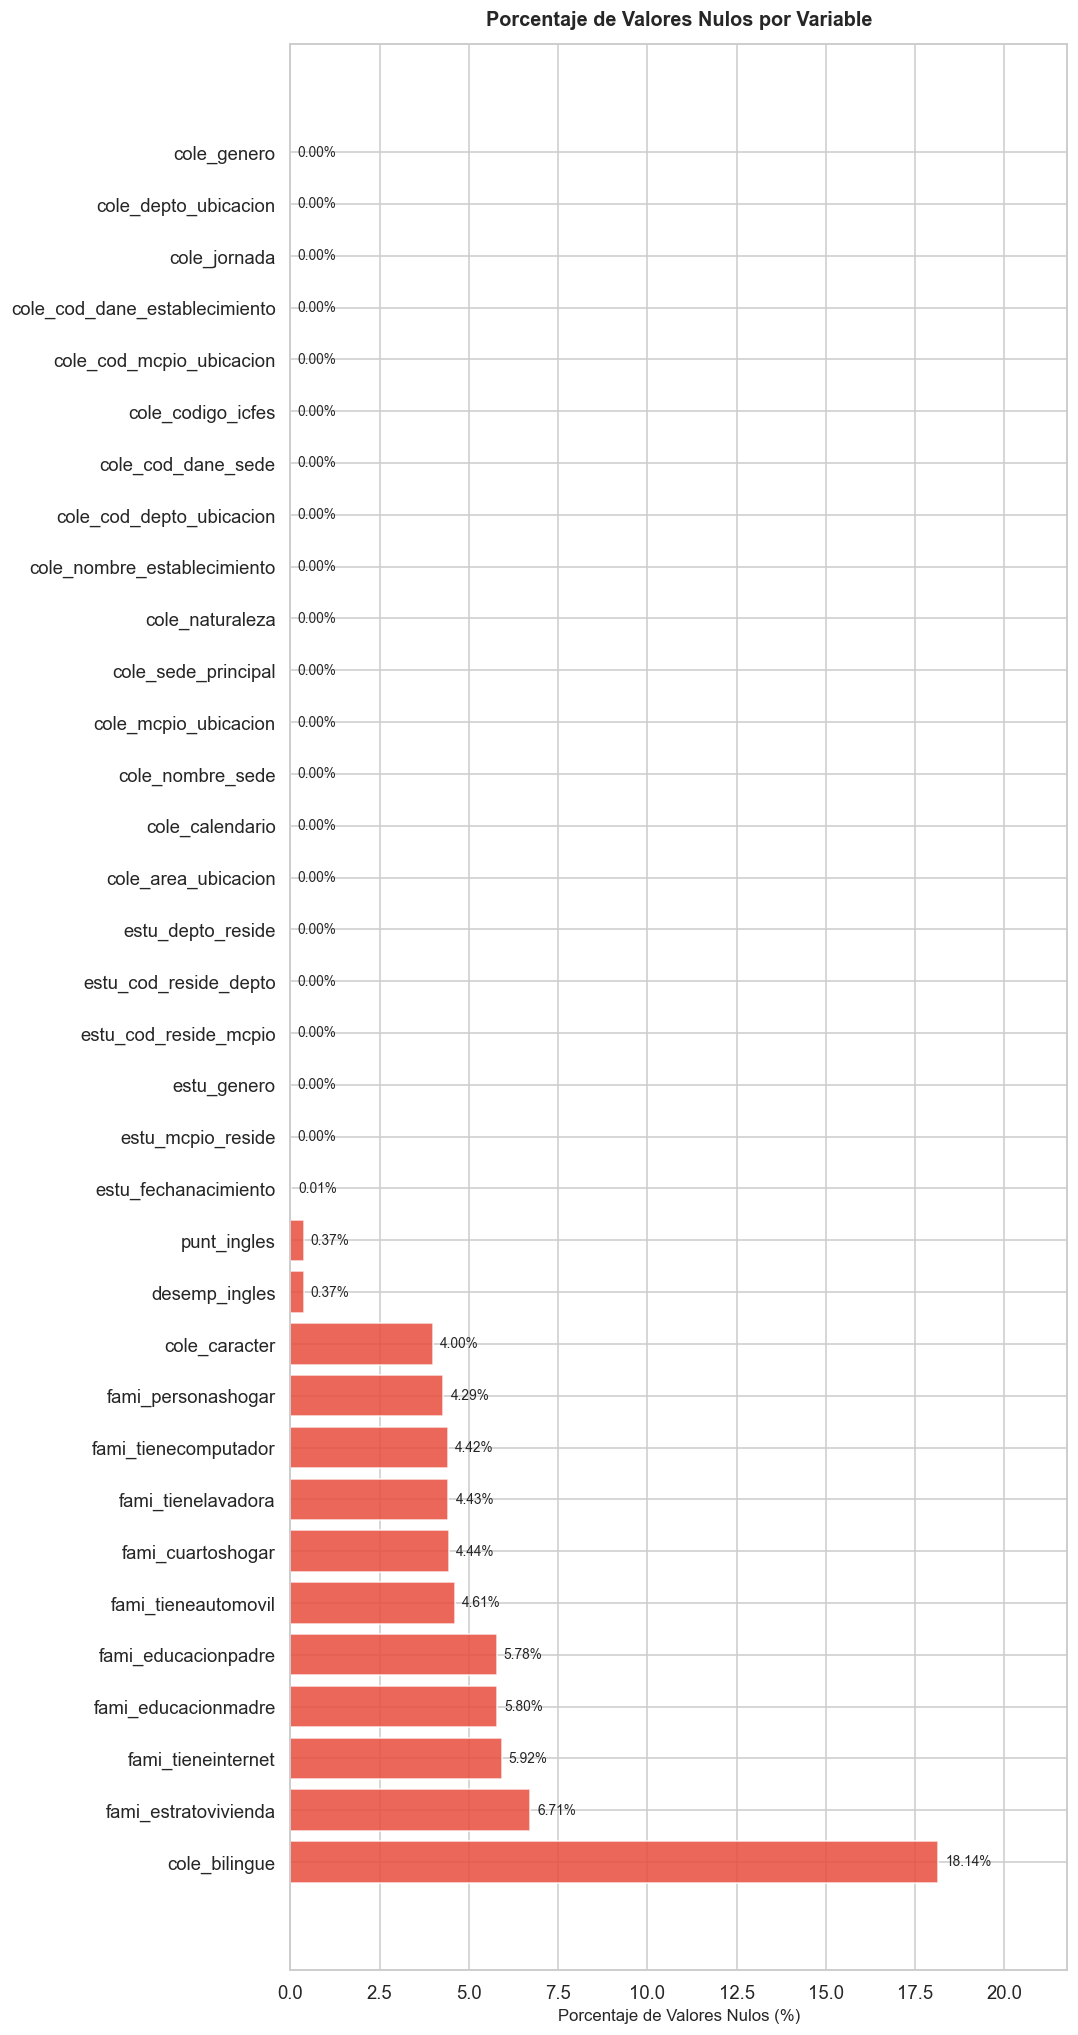

In [34]:
# ── Visualización de nulos ────────────────────────────────────────────────────
if len(nulos_df) > 0:
    fig, ax = plt.subplots(figsize=(10, max(4, len(nulos_df) * 0.55)))
    bars = ax.barh(
        nulos_df['Variable'], nulos_df['Pct'],
        color='#E74C3C', edgecolor='white', alpha=0.85
    )
    ax.set_xlabel('Porcentaje de Valores Nulos (%)', fontsize=11)
    ax.set_title('Porcentaje de Valores Nulos por Variable',
                 fontsize=13, fontweight='bold', pad=12)
    ax.set_xlim(0, nulos_df['Pct'].max() * 1.2)
    for bar, pct in zip(bars, nulos_df['Pct']):
        ax.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height() / 2,
                f'{pct:.2f}%', va='center', fontsize=9)
    plt.tight_layout()
    plt.savefig('images/eda/fig_nulos.png', dpi=110, bbox_inches='tight')
    plt.show()


**Interpretación:**
- `cole_bilingue` presenta ≈18% de nulos: probable omisión en el reporte administrativo de los colegios.
- `fami_estratovivienda` tiene ≈7% de nulos: variable de autodeclaración con mayor tasa de omisión voluntaria.
- El patrón de nulos en variables socioeconómicas sugiere que los datos **no son faltantes al azar** (MNAR),
  lo que motiva evaluar dos estrategias de manejo distintas (ver Sección 5.3).


### 4.3 Análisis de Duplicados

La variable `estu_consecutivo` es el identificador único de cada estudiante en cada período de presentación.

In [35]:
# ── Detección de duplicados vía estu_consecutivo ─────────────────────────────
mask_dup      = df_raw.duplicated(subset=['estu_consecutivo'], keep=False)
n_dup         = mask_dup.sum()
n_unicos      = df_raw['estu_consecutivo'].nunique()
total         = len(df_raw)

print(f'Total de registros            : {total:,}')
print(f'Valores únicos estu_consecutivo: {n_unicos:,}')
print(f'Registros duplicados           : {n_dup:,}  ({n_dup/total*100:.3f}%)')

if n_dup > 0:
    # Ejemplo de duplicados
    ej_cols = [c for c in ['estu_consecutivo','periodo','estu_genero',
                            'fami_estratovivienda','punt_global'] if c in df_raw.columns]
    print('\n📋 Muestra de registros duplicados:')
    display(df_raw[mask_dup].sort_values('estu_consecutivo')[ej_cols].head(8))


Total de registros            : 1,085,937
Valores únicos estu_consecutivo: 552,841
Registros duplicados           : 1,065,888  (98.154%)

📋 Muestra de registros duplicados:


,estu_consecutivo,periodo,estu_genero,fami_estratovivienda,punt_global
442777,SB11202240000034,20224,M,Sin Estrato,197
972411,SB11202240000034,20224,M,Sin Estrato,197
197572,SB11202240000036,20224,M,Estrato 3,159
727192,SB11202240000036,20224,M,Estrato 3,159
209846,SB11202240000037,20224,F,Estrato 5,149
739459,SB11202240000037,20224,F,Estrato 5,149
222405,SB11202240000039,20224,F,Estrato 2,156
752018,SB11202240000039,20224,F,Estrato 2,156


In [36]:
# ── Verificar si los duplicados son registros exactos o tienen diferencias ────
if n_dup > 0:
    primer_dup = df_raw[mask_dup]['estu_consecutivo'].value_counts().index[0]
    grupo      = df_raw[df_raw['estu_consecutivo'] == primer_dup]
    print(f'Ejemplo de duplicado (consecutivo={primer_dup}):')
    print(f'  Apariciones         : {len(grupo)}')
    print(f'  ¿Son filas idénticas?: {grupo.duplicated(keep=False).all()}')

print('\n📝 Decisión: se eliminarán los registros con estu_consecutivo duplicado')
print('   (keep=First), dejando un único registr asociado a cada estudiante.')


Ejemplo de duplicado (consecutivo=SB11202240167377):
  Apariciones         : 4
  ¿Son filas idénticas?: True

📝 Decisión: se eliminarán los registros con estu_consecutivo duplicado
   (keep=First), dejando un único registr asociado a cada estudiante.


### 4.4 Distribución del Puntaje Global

Analizamos la distribución de `punt_global` para fundamentar los umbrales de categorización de la variable objetivo.

In [37]:
# ── Convertir puntajes a numérico ─────────────────────────────────────────────
SCORE_COLS = [c for c in ['punt_ingles','punt_matematicas','punt_c_naturales',
                            'punt_sociales_ciudadanas','punt_lectura_critica','punt_global']
              if c in df_raw.columns]

for col in SCORE_COLS:
    df_raw[col] = pd.to_numeric(df_raw[col], errors='coerce')

print('Estadísticas descriptivas — puntajes:')
display(df_raw[SCORE_COLS].describe().T.round(2))


Estadísticas descriptivas — puntajes:


,count,mean,std,min,25%,50%,75%,max
punt_ingles,1081879.0000,50.1100,13.3300,0.0000,39.0000,49.0000,58.0000,100.0000
punt_matematicas,1085937.0000,50.7100,12.3000,0.0000,42.0000,51.0000,59.0000,100.0000
punt_c_naturales,1085937.0000,49.2000,10.4600,0.0000,41.0000,48.0000,57.0000,100.0000
punt_sociales_ciudadanas,1085937.0000,47.8300,12.0000,0.0000,38.0000,47.0000,57.0000,100.0000
punt_lectura_critica,1085937.0000,52.9100,10.8200,0.0000,45.0000,53.0000,61.0000,100.0000
punt_global,1085937.0000,250.7800,52.2500,0.0000,210.0000,247.0000,288.0000,477.0000


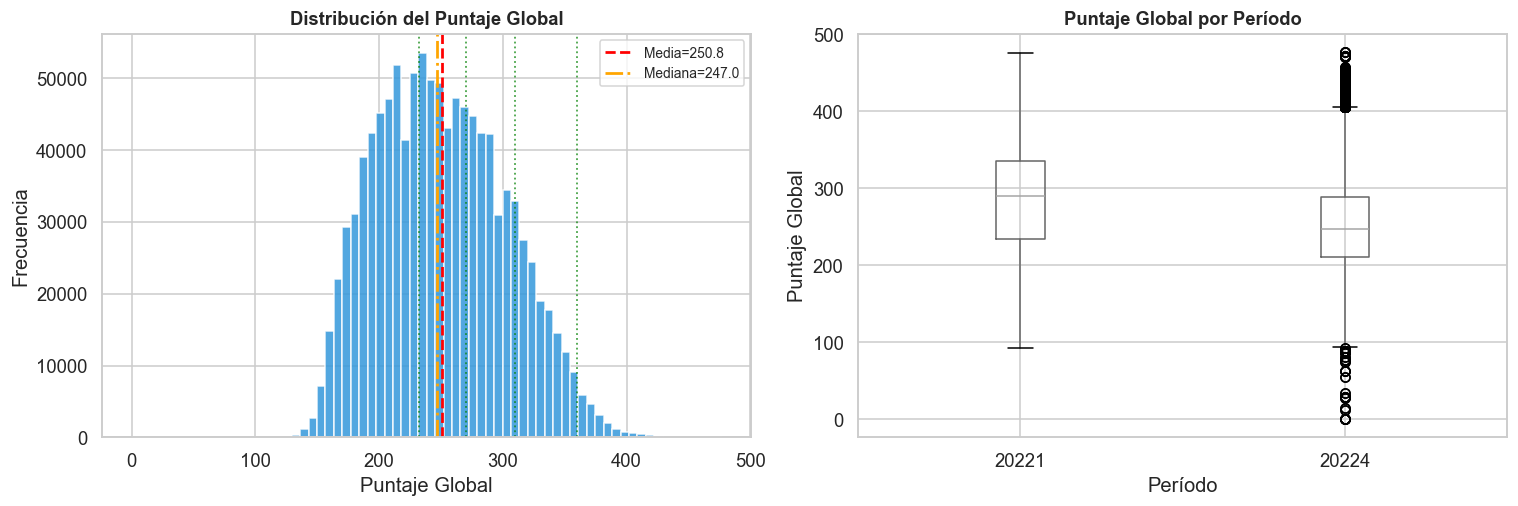

In [38]:
# ── Distribución del puntaje global ──────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma
axes[0].hist(df_raw['punt_global'].dropna(), bins=70,
             color='#3498DB', edgecolor='white', alpha=0.85)
media   = df_raw['punt_global'].mean()
mediana = df_raw['punt_global'].median()
axes[0].axvline(media,   color='red',    linestyle='--', lw=1.8, label=f'Media={media:.1f}')
axes[0].axvline(mediana, color='orange', linestyle='-.', lw=1.8, label=f'Mediana={mediana:.1f}')
for x, lbl in zip([232, 270, 310, 360], ['Muy Bajo|Bajo', 'Bajo|Aceptable', 'Aceptable|Bueno', 'Bueno|Excelente']):
    axes[0].axvline(x, color='green', linestyle=':', lw=1.2, alpha=0.7)
axes[0].set_title('Distribución del Puntaje Global', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Puntaje Global'); axes[0].set_ylabel('Frecuencia')
axes[0].legend(fontsize=9)

# Boxplot por período
df_raw.boxplot(column='punt_global', by='periodo', ax=axes[1])
axes[1].set_title('Puntaje Global por Período', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Período'); axes[1].set_ylabel('Puntaje Global')
plt.suptitle('')

plt.tight_layout()
plt.savefig('images/eda/fig_dist_puntaje.png', dpi=110, bbox_inches='tight')
plt.show()


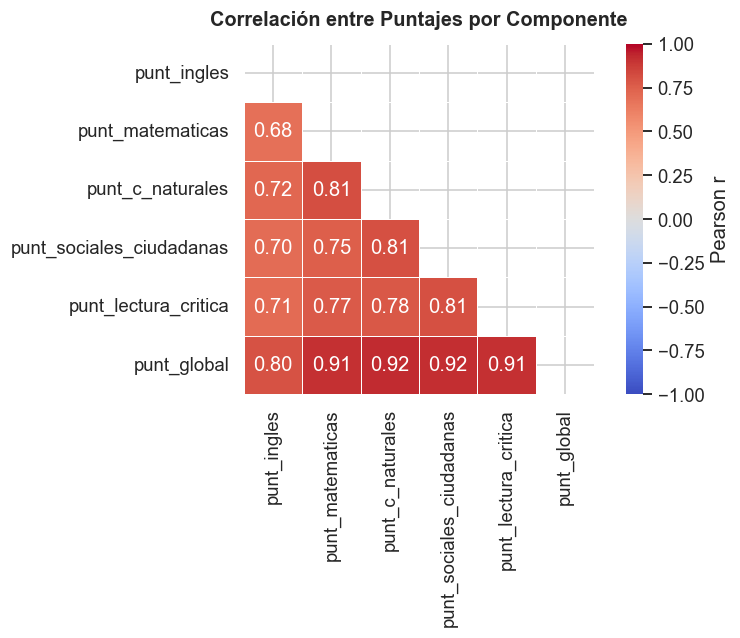

📝 Alta correlación entre componentes y puntaje global → confirma la exclusión
   de los puntajes como predictores (evita data leakage).


In [39]:
# ── Correlación entre puntajes ────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))
corr = df_raw[SCORE_COLS].dropna().corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            mask=mask, ax=ax, linewidths=0.4, square=True,
            vmin=-1, vmax=1, cbar_kws={'label': 'Pearson r'})
ax.set_title('Correlación entre Puntajes por Componente',
             fontsize=13, fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig('images/eda/fig_correlacion.png', dpi=110, bbox_inches='tight')
plt.show()

print('📝 Alta correlación entre componentes y puntaje global → confirma la exclusión')
print('   de los puntajes como predictores (evita data leakage).')


### 4.5 Variables Socioeconómicas y del Establecimiento

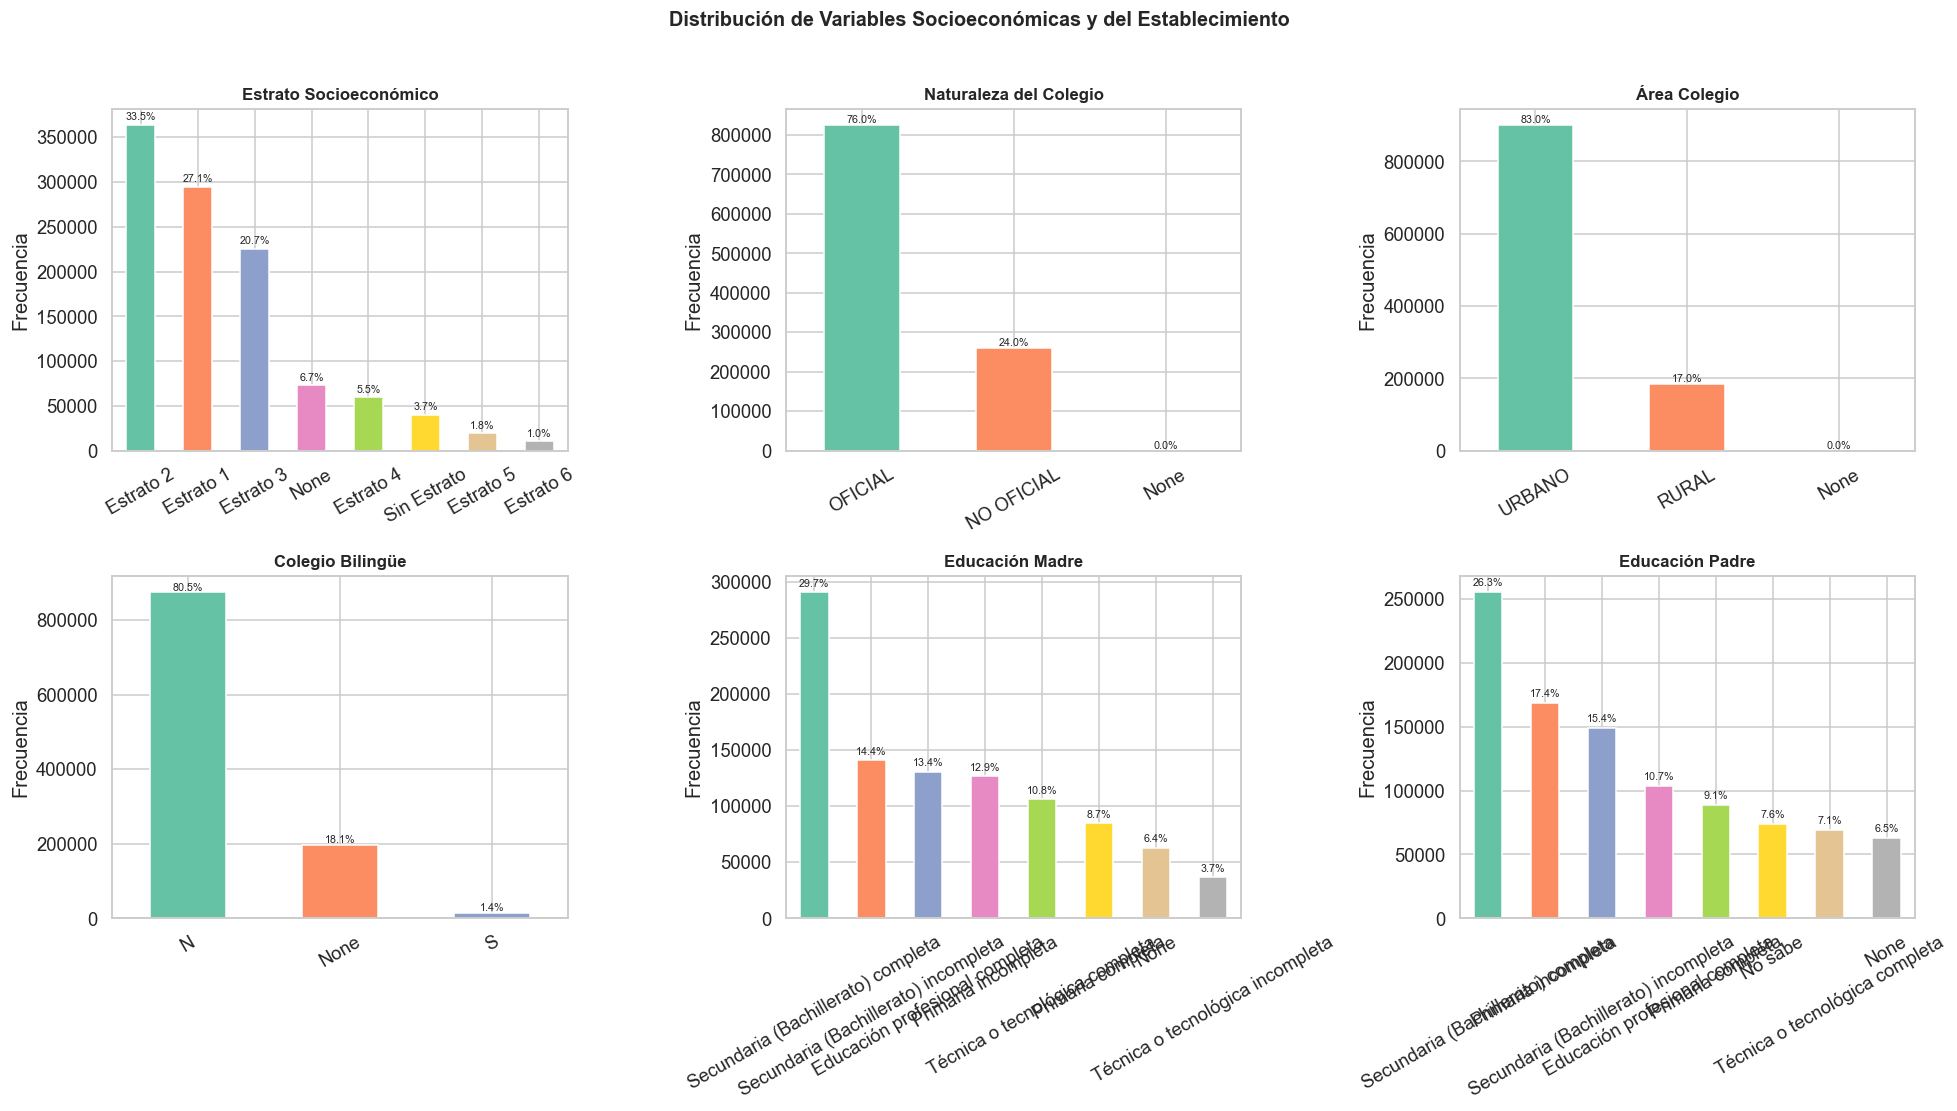

In [40]:
# ── Distribución de variables categóricas clave ───────────────────────────────
cat_interest = [
    ('fami_estratovivienda', 'Estrato Socioeconómico'),
    ('cole_naturaleza',      'Naturaleza del Colegio'),
    ('cole_area_ubicacion',  'Área Colegio'),
    ('cole_bilingue',        'Colegio Bilingüe'),
    ('fami_educacionmadre',  'Educación Madre'),
    ('fami_educacionpadre',  'Educación Padre'),
]
cat_interest = [(c, l) for c, l in cat_interest if c in df_raw.columns]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
palette = sns.color_palette('Set2', 10)

for i, (col, label) in enumerate(cat_interest[:6]):
    vc    = df_raw[col].value_counts(dropna=False).head(8)
    total = vc.sum()
    vc.plot(kind='bar', ax=axes[i], color=palette[:len(vc)], edgecolor='white')
    axes[i].set_title(label, fontsize=11, fontweight='bold')
    axes[i].set_xlabel(''); axes[i].set_ylabel('Frecuencia')
    axes[i].tick_params(axis='x', rotation=30)
    for bar in axes[i].patches:
        pct = bar.get_height() / total * 100
        axes[i].text(bar.get_x() + bar.get_width()/2,
                     bar.get_height() + total * 0.005,
                     f'{pct:.1f}%', ha='center', fontsize=7)

for j in range(len(cat_interest), 6):
    axes[j].set_visible(False)

plt.suptitle('Distribución de Variables Socioeconómicas y del Establecimiento',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('images/eda/fig_cat_vars.png', dpi=110, bbox_inches='tight')
plt.show()


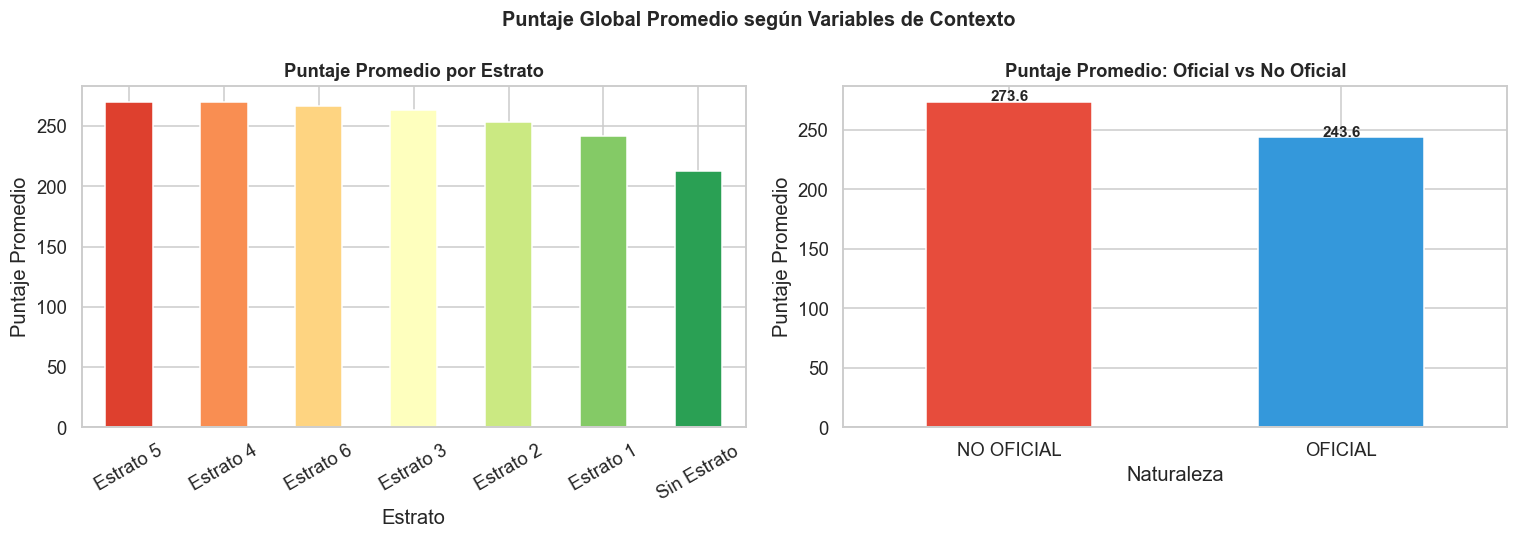

In [43]:
# ── Puntaje global promedio por estrato y naturaleza ─────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Por estrato
if 'fami_estratovivienda' in df_raw.columns:
    media_est = (
        df_raw.groupby('fami_estratovivienda')['punt_global']
        .mean().sort_values(ascending=False)
    )
    media_est.plot(kind='bar', ax=axes[0],
                   color=sns.color_palette('RdYlGn', len(media_est)), edgecolor='white')
    axes[0].set_title('Puntaje Promedio por Estrato', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Estrato'); axes[0].set_ylabel('Puntaje Promedio')
    axes[0].tick_params(axis='x', rotation=30)

# Por naturaleza del colegio
if 'cole_naturaleza' in df_raw.columns:
    media_nat = df_raw.groupby('cole_naturaleza')['punt_global'].mean().sort_values(ascending=False)
    media_nat.plot(kind='bar', ax=axes[1],
                   color=['#E74C3C', '#3498DB'][:len(media_nat)], edgecolor='white')
    axes[1].set_title('Puntaje Promedio: Oficial vs No Oficial', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Naturaleza'); axes[1].set_ylabel('Puntaje Promedio')
    axes[1].tick_params(axis='x', rotation=0)
    for bar in axes[1].patches:
        axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                     f'{bar.get_height():.1f}', ha='center', fontsize=10, fontweight='bold')

plt.suptitle('Puntaje Global Promedio según Variables de Contexto',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('images/eda/fig_puntaje_contexto.png', dpi=110, bbox_inches='tight')
plt.show()


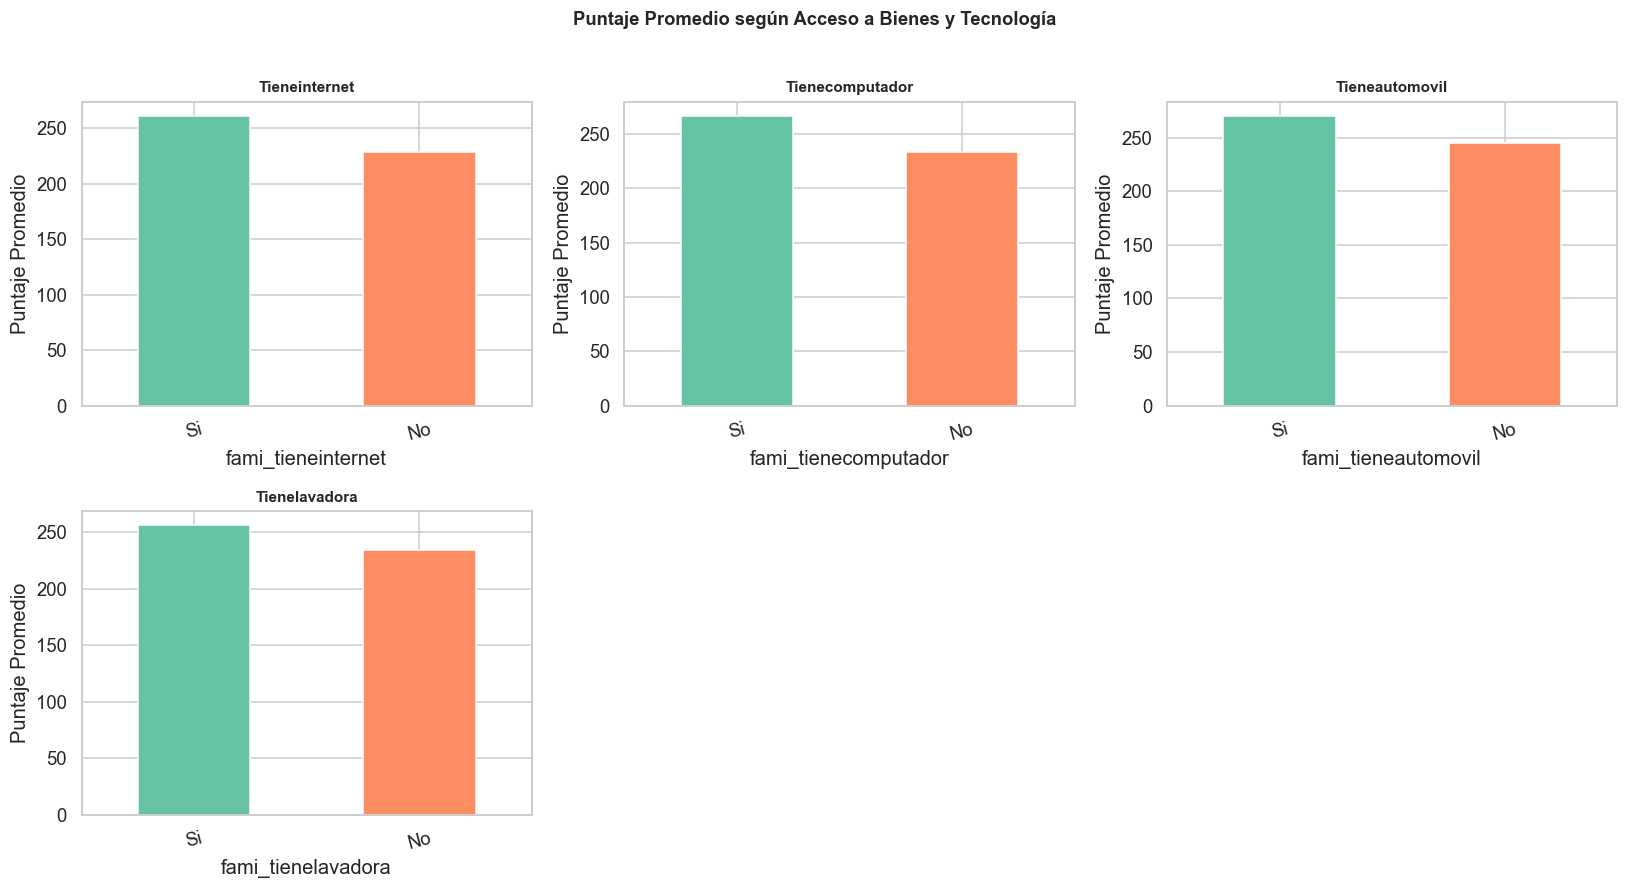

In [45]:
# ── Acceso a tecnología y puntaje ────────────────────────────────────────────
tech_vars = [v for v in ['fami_tieneinternet','fami_tienecomputador',
                          'fami_tienetelevisor','fami_tieneautomovil',
                          'fami_tienehornomicroondas','fami_tienelavadora']
             if v in df_raw.columns]

if tech_vars:
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    axes = axes.flatten()
    for i, var in enumerate(tech_vars[:6]):
        media_g = df_raw.groupby(var)['punt_global'].mean().sort_values(ascending=False)
        media_g.plot(kind='bar', ax=axes[i],
                     color=sns.color_palette('Set2', len(media_g)), edgecolor='white')
        axes[i].set_title(var.replace('fami_', '').replace('_', ' ').title(),
                          fontsize=10, fontweight='bold')
        axes[i].set_ylabel('Puntaje Promedio')
        axes[i].tick_params(axis='x', rotation=15)
    for j in range(len(tech_vars), 6):
        axes[j].set_visible(False)
    plt.suptitle('Puntaje Promedio según Acceso a Bienes y Tecnología',
                 fontsize=12, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.savefig('images/fig_tecnologia.png', dpi=110, bbox_inches='tight')
    plt.show()


### 4.6 Detección de Outliers (Criterio IQR)

In [47]:
# ── Outliers en puntajes ─────────────────────────────────────────────────────
outlier_data = []
for col in SCORE_COLS:
    Q1, Q3 = df_raw[col].quantile(0.25), df_raw[col].quantile(0.75)
    IQR    = Q3 - Q1
    lo, hi = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    n_out  = ((df_raw[col] < lo) | (df_raw[col] > hi)).sum()
    outlier_data.append({
        'Variable': col, 'Q1': Q1, 'Q3': Q3, 'IQR': IQR,
        'Lim_Inf': lo, 'Lim_Sup': hi,
        'Outliers': n_out, 'Pct': round(n_out / len(df_raw) * 100, 3)
    })

print('Análisis de Outliers (IQR):')
display(pd.DataFrame(outlier_data))
print('\n📝 Los puntajes del Saber 11 tienen rango acotado por diseño del instrumento.')
print('   Los outliers son valores válidos que representan rendimientos atípicos.')
print('   → No se eliminan outliers de los puntajes.')


Análisis de Outliers (IQR):


,Variable,Q1,Q3,IQR,Lim_Inf,Lim_Sup,Outliers,Pct
0,punt_ingles,39.0000,58.0000,19.0000,10.5000,86.5000,8285,0.7630
1,punt_matematicas,42.0000,59.0000,17.0000,16.5000,84.5000,2485,0.2290
2,punt_c_naturales,41.0000,57.0000,16.0000,17.0000,81.0000,374,0.0340
3,punt_sociales_ciudadanas,38.0000,57.0000,19.0000,9.5000,85.5000,147,0.0140
4,punt_lectura_critica,45.0000,61.0000,16.0000,21.0000,85.0000,1088,0.1000
5,punt_global,210.0000,288.0000,78.0000,93.0000,405.0000,1600,0.1470



📝 Los puntajes del Saber 11 tienen rango acotado por diseño del instrumento.
   Los outliers son valores válidos que representan rendimientos atípicos.
   → No se eliminan outliers de los puntajes.


## 5. Preprocesamiento de Datos

### 5.1 Definición de la Variable Objetivo

Para los experimentos, convertimos `punt_global` en una variable categórica de 3 o 2 niveles de desempeño, para anlizar el desempeño del modelo en ambos escenarios.
Los umbrales se definen con base en la distribución observada y referencias interpretativas del ICFES:

**Rangos con 3 niveles**

| Nivel | Rango Puntaje |
|-------|--------------|
| Bajo  | 0 – 225 |
| Básico    | 225 – 335 |
| Alto | 335 – 500 |


**Rangos con 2 niveles**

| Nivel | Rango Puntaje |
|-------|--------------|
| Bajo  | 0 – 250 |
| Alto | 250 – 500 |



Estos umbrales aseguran que cada categoría contenga una masa de datos suficiente
para el entrenamiento y son interpretables en términos del escalamiento de la prueba (0–500).


In [ ]:
# ── Variable objetivo ────────────────────────────────────────────────────────
df = df_raw.copy()
df_2 = df_raw.copy()
df['punt_global'] = pd.to_numeric(df['punt_global'], errors='coerce')
df_2['punt_global'] = pd.to_numeric(df_2['punt_global'], errors='coerce')

# ========= OPCIÓN 1: Tres clases (Bajo, Básico, Alto) =========

LABELS_3 = ['Bajo', 'Básico', 'Alto']
BINS_3   = [0, 225, 335, 500]

df['nivel_desempeno'] = pd.cut(
    df['punt_global'], bins=BINS_3, labels=LABELS_3,
    include_lowest=True, right=True
)

print('✅ Variable objetivo creada: nivel_desempeno (3 clases)')
dist = df['nivel_desempeno'].value_counts().reindex(LABELS_3)
pct  = (dist / dist.sum() * 100).round(2)
display(pd.DataFrame({'Clase': LABELS_3, 'Conteo': dist.values, '% Total': pct.values}))


# =========== OPCIÓN 2: Dos clases (Bajo, Alto) ===========

LABELS_2 = ['Bajo', 'Alto']
BINS_2   = [0, 250, 500]

df_2['nivel_desempeno'] = pd.cut(
    df_2['punt_global'], bins=BINS_2, labels=LABELS_2,
    include_lowest=True, right=True
)

print('✅ Variable objetivo creada: nivel_desempeno (2 clases)')
dist_2 = df_2['nivel_desempeno'].value_counts().reindex(LABELS_2)
pct  = (dist_2 / dist_2.sum() * 100).round(2)
display(pd.DataFrame({'Clase': LABELS_2, 'Conteo': dist_2.values, '% Total': pct.values}))

✅ Variable objetivo creada: nivel_desempeno


,Clase,Conteo,% Total
0,Bajo,383754,35.3400
1,Básico,634657,58.4400
2,Alto,67526,6.2200


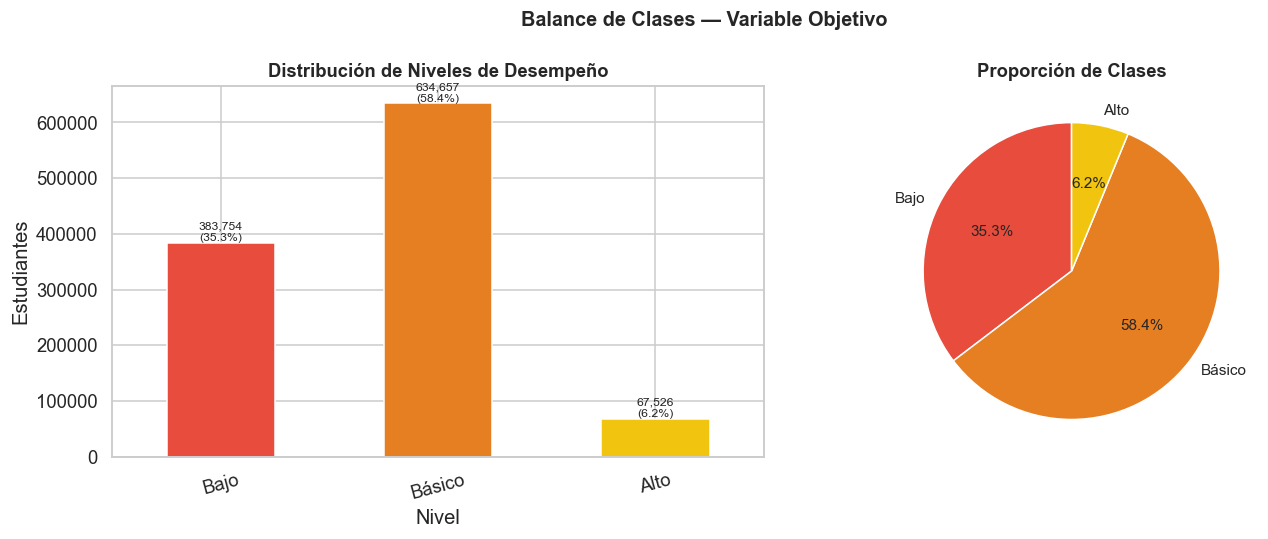

In [ ]:
# ── Visualización del balance de clases ──────────────────────────────────────

COLORES = ['#E74C3C', '#E67E22', '#F1C40F']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ========== Visualización para 3 clases ==========

# Barras
dist.plot(kind='bar', ax=axes[0], color=COLORES, edgecolor='white')
axes[0].set_title('Distribución de Niveles de Desempeño',
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel('Nivel'); axes[0].set_ylabel('Estudiantes')
axes[0].tick_params(axis='x', rotation=15)
total_p = dist.sum()
for bar in axes[0].patches:
    axes[0].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + total_p * 0.003,
        f'{bar.get_height():,}\n({bar.get_height()/total_p*100:.1f}%)',
        ha='center', fontsize=8
    )

# Pie
dist.plot(kind='pie', ax=axes[1], autopct='%1.1f%%',
          colors=COLORES, startangle=90, textprops={'fontsize': 10})
axes[1].set_title('Proporción de Clases', fontsize=12, fontweight='bold')
axes[1].set_ylabel('')

plt.suptitle('Balance de Clases — Variable Objetivo (3 clases)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('images/fig_balance_clases.png', dpi=110, bbox_inches='tight')
plt.show()

# ========== Visualización para 2 clases ==========

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Barras
dist_2.plot(kind='bar', ax=axes[0], color=COLORES[:2], edgecolor='white')
axes[0].set_title('Distribución de Niveles de Desempeño',
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel('Nivel'); axes[0].set_ylabel('Estudiantes')
axes[0].tick_params(axis='x', rotation=15)
total_p = dist_2.sum()
for bar in axes[0].patches:
    axes[0].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + total_p * 0.003,
        f'{bar.get_height():,}\n({bar.get_height()/total_p*100:.1f}%)',
        ha='center', fontsize=8
    )

# Pie
dist_2.plot(kind='pie', ax=axes[1], autopct='%1.1f%%',
            colors=COLORES[:2], startangle=90, textprops={'fontsize': 10})
axes[1].set_title('Proporción de Clases', fontsize=12, fontweight='bold')
axes[1].set_ylabel('')

plt.suptitle('Balance de Clases — Variable Objetivo (2 clases)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('images/fig_balance_clases_2.png', dpi=110, bbox_inches='tight')
plt.show()


### 5.2 Selección de Variables Predictoras

Se excluyen los puntajes (data leakage), los IDs y el período. Inicialmente se usan **todas las variables disponibles**.

In [50]:
# ── Definición de columnas ────────────────────────────────────────────────────
EXCLUDE_COLS = SCORE_COLS + [
    'estu_consecutivo',
    'periodo',
    'nivel_desempeno',
    'cole_cod_depto_ubicacion',

    # =========================
    # Variables adicionales
    # =========================
    'estu_tipodocumento',
    'cole_cod_mcpio_ubicacion',
    'cole_cod_departamento_unicacion',
    'cole_codigo_icfes',
    'cole_nombre_establecimiento',
    'cole_nombre_sede',
    'estu_cod_depto_presentacion',
    'estu_cod_mcpio_presentacion',
    'estu_cod_reside_mcpio',
    'estu_fechanacimiento',
    'estu_mcpio_presentacion',
    'estu_mcpio_reside',
    'estu_pais_reside',
    'desemp_ingles',
    'cole_mcpio_ubicacion',
    'cole_codigo_icfes',
    'cole_cod_dane_sede',
    'cole_cod_dane_establecimiento',
    'estu_cod_mcpio_presentacion'
]


TARGET       = 'nivel_desempeno'

# Excluir variables de alta cardinalidad (>200 categorías → problemas de memoria/encoding)
alta_card = []
for col in df.columns:
    if col not in EXCLUDE_COLS and df[col].dtype == object:
        if df[col].nunique() > 200:
            alta_card.append(col)
            EXCLUDE_COLS.append(col)

if alta_card:
    print(f'⚠️  Excluidas por alta cardinalidad (>{200} cat.): {alta_card}')

FEATURES     = [c for c in df.columns if c not in EXCLUDE_COLS]
NUM_FEATURES = df[FEATURES].select_dtypes(include='number').columns.tolist()
CAT_FEATURES = df[FEATURES].select_dtypes(include=['object','category']).columns.tolist()

print(f'\nTotal features: {len(FEATURES)}')
print(f'  → Numéricas  : {len(NUM_FEATURES)} → {NUM_FEATURES}')
print(f'  → Categóricas: {len(CAT_FEATURES)} → {CAT_FEATURES}')



Total features: 26
  → Numéricas  : 0 → []
  → Categóricas: 26 → ['cole_area_ubicacion', 'cole_calendario', 'cole_caracter', 'cole_depto_ubicacion', 'cole_genero', 'cole_jornada', 'cole_naturaleza', 'cole_sede_principal', 'estu_cod_reside_depto', 'estu_depto_presentacion', 'estu_depto_reside', 'estu_estadoinvestigacion', 'estu_estudiante', 'estu_genero', 'estu_nacionalidad', 'estu_privado_libertad', 'fami_cuartoshogar', 'fami_educacionmadre', 'fami_educacionpadre', 'fami_estratovivienda', 'fami_personashogar', 'fami_tieneautomovil', 'fami_tienecomputador', 'fami_tieneinternet', 'fami_tienelavadora', 'cole_bilingue']


In [51]:
# ── Resumen de columnas: tipo, nulos y cardinalidad ──────────────────────────
resumen = pd.DataFrame({
    'Tipo'      : df_raw.dtypes.values,
    'No_Nulos'  : df_raw.notna().sum().values,
    'Nulos'     : df_raw.isna().sum().values,
    'Pct_Nulos' : (df_raw.isna().sum().values / len(df_raw) * 100).round(2),
    'Unicos'    : df_raw.nunique().values,
}, index=df_raw.columns)

print('📊 Resumen del dataset (ordenado por % de nulos):')
display(resumen.sort_values('Pct_Nulos', ascending=False))


📊 Resumen del dataset (ordenado por % de nulos):


,Tipo,No_Nulos,Nulos,Pct_Nulos,Unicos
cole_bilingue,object,888902,197035,18.1400,2
fami_estratovivienda,object,1013046,72891,6.7100,7
fami_tieneinternet,object,1021658,64279,5.9200,2
fami_educacionmadre,object,1022958,62979,5.8000,12
fami_educacionpadre,object,1023175,62762,5.7800,12
fami_tieneautomovil,object,1035916,50021,4.6100,2
fami_cuartoshogar,object,1037678,48259,4.4400,6
fami_tienelavadora,object,1037850,48087,4.4300,2
fami_tienecomputador,object,1037997,47940,4.4100,2
fami_personashogar,object,1039396,46541,4.2900,5


### 5.3 Limpieza Pre-Modelado: Duplicados y Registros Sin Target

In [ ]:
# ── Eliminar duplicados (estu_consecutivo) ────────────────────────────────────
n_antes = len(df)
df = df[~df.duplicated(subset=['estu_consecutivo'], keep='first')].reset_index(drop=True)
df_2 = df_2[~df_2.duplicated(subset=['estu_consecutivo'], keep='first')].reset_index(drop=True)
print(f'Registros eliminados por duplicado: {n_antes - len(df):,}')

# ── Eliminar filas sin nivel_desempeno (sin punt_global válido) ────────────────
df = df.dropna(subset=['nivel_desempeno']).reset_index(drop=True)
df_2 = df_2.dropna(subset=['nivel_desempeno']).reset_index(drop=True)
print(f'Registros con target válido: {len(df):,}')

# ── Codificación numérica del target ──────────────────────────────────────────
label2idx = {l: i for i, l in enumerate(LABELS_3)}
label2idx_2 = {l: i for i, l in enumerate(LABELS_2)}
df['target'] = df['nivel_desempeno'].map(label2idx)
df_2['target'] = df_2['nivel_desempeno'].map(label2idx_2)

print('\nCodificación del target (3 clases):')
for l, i in label2idx.items():
    print(f'  {i} → {l}')

print('\nCodificación del target (2 clases):')
for l, i in label2idx_2.items():
    print(f'  {i} → {l}')



Registros eliminados por duplicado: 533,096
Registros con target válido: 552,841

Codificación del target:
  0 → Bajo
  1 → Básico
  2 → Alto


### 5.4 Dos Experimentos de Manejo de Nulos

Dado que los valores nulos en variables socioeconómicas son **Missing Not At Random (MNAR)**,
implementamos dos estrategias paralelas:

**Experimento 1 — Eliminación de nulos:**
Se eliminan todas las filas con al menos un valor nulo en las features predictoras.
- Justificación: La cantidad restante de datos sigue siendo estadísticamente suficiente.
  Imputar variables como `fami_estratovivienda` puede introducir sesgo sistemático porque
  la ausencia no es aleatoria (familias de estratos bajos omiten más frecuentemente este dato).

**Experimento 2 — Imputación:**
- Variables numéricas → mediana (robusta a outliers).
- Variables categóricas → moda (valor más frecuente).
- Justificación: Permite retener más registros para el entrenamiento, lo que puede
  mejorar la generalización del modelo.


In [ ]:
# ── Subsets por experimento ───────────────────────────────────────────────────

# ================= Para 3 clases (Bajo, Básico, Alto) =================

X_all = df[FEATURES].copy()
y_all = df['target'].copy()

# Experimento 1: solo filas completamente limpias
mask_clean = X_all.notna().all(axis=1)
X_exp1, y_exp1 = X_all[mask_clean].reset_index(drop=True), y_all[mask_clean].reset_index(drop=True)

# Experimento 2: dataset completo (con nulos — se imputará en el pipeline)
X_exp2, y_exp2 = X_all.copy(), y_all.copy()



# ================= Para 2 clases (Bajo, Alto) =================
X_all_2 = df_2[FEATURES].copy()
y_all_2 = df_2['target'].copy()

# Experimento 1: solo filas completamente limpias
mask_clean_2 = X_all_2.notna().all(axis=1)
X_exp1_2, y_exp1_2 = X_all_2[mask_clean_2].reset_index(drop=True), y_all_2[mask_clean_2].reset_index(drop=True)

# Experimento 2: dataset completo (con nulos — se imputará en el pipeline)
X_exp2_2, y_exp2_2 = X_all_2.copy(), y_all_2.copy()

print(f'Exp 1 (Eliminación): {len(X_exp1):,} registros ({len(X_exp1)/len(X_all)*100:.1f}%)')
print(f'Exp 2 (Imputación):  {len(X_exp2):,} registros ({len(X_exp2)/len(X_all)*100:.1f}%)')



Exp 1 (Eliminación): 406,448 registros (73.5%)
Exp 2 (Imputación):  552,841 registros (100.0%)


In [ ]:
# ── División Train / Test estratificada (80/20) ────────────────────────────────
RANDOM_STATE = 42

# =========== Para 3 clases ===========

X_tr1, X_te1, y_tr1, y_te1 = train_test_split(
    X_exp1, y_exp1, test_size=0.20, random_state=RANDOM_STATE, stratify=y_exp1
)
X_tr2, X_te2, y_tr2, y_te2 = train_test_split(
    X_exp2, y_exp2, test_size=0.20, random_state=RANDOM_STATE, stratify=y_exp2
)

# =========== Para 2 clases ===========

X_tr1_2, X_te1_2, y_tr1_2, y_te1_2 = train_test_split(
    X_exp1_2, y_exp1_2, test_size=0.20, random_state=RANDOM_STATE, stratify=y_exp1_2
)
X_tr2_2, X_te2_2, y_tr2_2, y_te2_2 = train_test_split(
    X_exp2_2, y_exp2_2, test_size=0.20, random_state=RANDOM_STATE, stratify=y_exp2_2
)

print('División Train / Test (80/20, estratificada):')
print(f'  Exp 1 → Train: {len(X_tr1):,}  |  Test: {len(X_te1):,}')
print(f'  Exp 2 → Train: {len(X_tr2):,}  |  Test: {len(X_te2):,}')


División Train / Test (80/20, estratificada):
  Exp 1 → Train: 325,158  |  Test: 81,290
  Exp 2 → Train: 442,272  |  Test: 110,569


### 5.5 Definición de Pipelines de Preprocesamiento

In [ ]:
# Experimento 1: sin imputación (datos ya limpios)
proc_e1 = ColumnTransformer([
    ('num', StandardScaler(), NUM_FEATURES),
    ('cat', OneHotEncoder(handle_unknown='ignore'), CAT_FEATURES)
], remainder='drop')

# Experimento 2: con imputación antes de escalar/codificar
proc_e2 = ColumnTransformer([
    ('num', Pipeline([
        ('imp', SimpleImputer(strategy='median')),
        ('sc',  StandardScaler())
    ]), NUM_FEATURES),

    ('cat', Pipeline([
        ('imp', SimpleImputer(strategy='most_frequent')),
        ('enc', OneHotEncoder(handle_unknown='ignore'))
    ]), CAT_FEATURES)

], remainder='drop')

print('✅ Preprocesadores definidos.')
print('  Exp 1: StandardScaler + OneHotEncoder (sin imputación)')
print('  Exp 2: SimpleImputer(median/moda) + StandardScaler + OneHotEncoder')

✅ Preprocesadores definidos.
  Exp 1: StandardScaler + OneHotEncoder (sin imputación)
  Exp 2: SimpleImputer(median/moda) + StandardScaler + OneHotEncoder


## 6. Entrenamiento y Evaluación de Modelos

Implementamos cuatro modelos para cada experimento:

| Modelo | Tipo | Justificación |
|--------|------|--------------|
| Regresión Logística | Lineal | Baseline interpretable |
| Random Forest | Ensamble (bagging) | Robusto, no lineal, importancia nativa |
| XGBoost | Ensamble (boosting) | Estado del arte en datos tabulares |
| MLP (TF/Keras) | Red neuronal profunda | Captura interacciones complejas |

En los Notebooks asociados a este proyecto se encuentran las aplicaciones de cada uno de los modelos mencionados. Cada notebook tiene el nombre del modelo que se aplicó:

- random_forest.ipynb
- xgboost.ipynb
-
-
